In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm

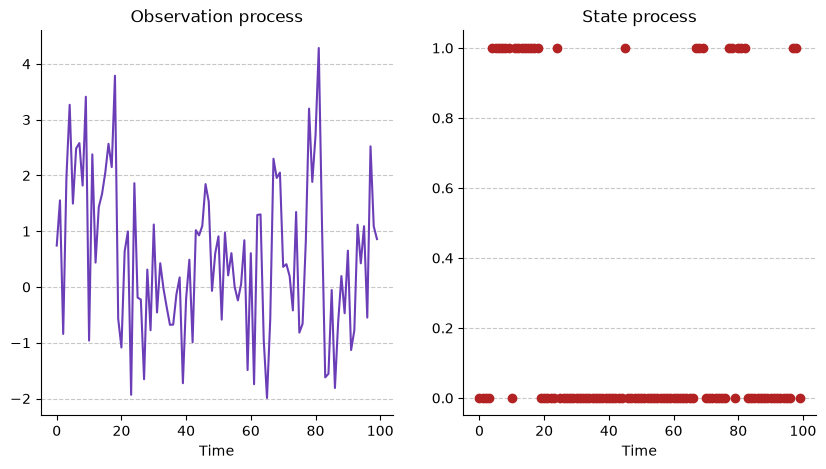

In [22]:
np.random.seed(0)

# Transition probability matrix
Gamma = np.array([[0.9, 0.1], [0.3, 0.7]])

# Define the 
m = 2
states = np.arange(m)

# Stationary distribution
A = np.vstack([(Gamma.T - np.eye(m))[:-1], np.ones(m)])
b = np.zeros(m); b[-1] = 1
delta = np.linalg.solve(A, b)

# Observaton process parameters
mu = np.array([0, 2])
sigma = np.array([1, 1])

# Arrays for the results
T = 100
C = np.zeros(T, dtype=int)
Y = np.zeros(T)

# Initial values
C[0] = np.random.choice(states, p=delta)
Y[0] = np.random.normal(loc=mu[C[0]], scale=sigma[C[0]])

for t in range(1, T):
    # We choose
    C[t] = np.random.choice(states, p=Gamma[C[t-1]])
    Y[t] = np.random.normal(loc=mu[C[t]], scale=sigma[C[t]])


# Plots
fig, ax = plt.subplots(ncols=2, figsize=(10,5))

ax[0].plot(np.arange(T), Y, color='#6B3EB8') # Observation process
ax[0].set_title("Observation process")

ax[1].scatter(np.arange(T), C, c='firebrick') # State process
ax[1].set_title("State process")

for i in range(2):
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["right"].set_visible(False)
    ax[i].grid(True, axis='y', linestyle='--', alpha=0.7)
    ax[i].set_axisbelow(True)
    ax[i].set_xlabel("Time")

In [23]:
np.random.seed(0)

# Transition probability matrix
Gamma = np.array([[0.9, 0.1], [0.3, 0.7]])

m = 2
states = np.arange(m)

# Stationary distribution
A = np.vstack([(Gamma.T - np.eye(m))[:-1], np.ones(m)])
b = np.zeros(m); b[-1] = 1
delta = np.linalg.solve(A, b)

# Observation process parameters
mu = np.array([0, 2])
sigma = np.array([1, 1])

# Simulate data
T = 100
C = np.zeros(T, dtype=int)
Y = np.zeros(T)

C[0] = np.random.choice(states, p=delta)
Y[0] = np.random.normal(loc=mu[C[0]], scale=sigma[C[0]])

for t in range(1, T):
    C[t] = np.random.choice(states, p=Gamma[C[t-1]])
    Y[t] = np.random.normal(loc=mu[C[t]], scale=sigma[C[t]])

#hi = delta.copy()

# Forward np.exp(algorithm with scalin)g
phi = delta.copy()
log_L_T = 0.0

P0 = np.diag(norm.pdf(Y[0], loc=mu, scale=sigma))
v = phi @ P0
w = v.sum()
log_L_T += np.log(w)
phi = v / w

for t in range(1, T):
    Pt = np.diag(norm.pdf(Y[t], loc=mu, scale=sigma))
    v = phi @ Gamma @ Pt
    w = v.sum()
    log_L_T += np.log(w)
    phi = v / w

print(np.exp(log_L_T))
print(log_L_T)

3.463108345992312e-71
-162.241375050903


In [ ]:
np.random.seed(0)

# Parámetros verdaderos
Gamma = np.array([[0.9, 0.1], [0.3, 0.7]])
m = 2
states = np.arange(m)

A = np.vstack([(Gamma.T - np.eye(m))[:-1], np.ones(m)])
b = np.zeros(m); b[-1] = 1
delta = np.linalg.solve(A, b)

mu = np.array([0, 2])
sigma = np.array([1, 1])

# Simulación
T = 5000
C = np.zeros(T, dtype=int)
Y = np.zeros(T)

C[0] = np.random.choice(states, p=delta)
Y[0] = np.random.normal(loc=mu[C[0]], scale=sigma[C[0]])

for t in range(1, T):
    C[t] = np.random.choice(states, p=Gamma[C[t-1]])
    Y[t] = np.random.normal(loc=mu[C[t]], scale=sigma[C[t]])

# Log-verosimilitud negativa
def neg_log_likelihood(params):
    tau = params[0:2]
    mu_ = params[2:4]
    sigma_ = np.exp(params[4:6])

    Gamma_ = np.eye(m)
    Gamma_[0, 1] = np.exp(tau[0])
    Gamma_[1, 0] = np.exp(tau[1])
    Gamma_ = Gamma_ / Gamma_.sum(axis=1, keepdims=True)

    A_ = np.vstack([(Gamma_.T - np.eye(m))[:-1], np.ones(m)])
    b_ = np.zeros(m); b_[-1] = 1
    delta_ = np.linalg.solve(A_, b_)

    phi = delta_.copy()
    log_L_T = 0.0

    P0 = np.diag(norm.pdf(Y[0], loc=mu_, scale=sigma_))
    v = phi @ P0
    w = v.sum()
    log_L_T += np.log(w)
    phi = v / w

    for t in range(1, T):
        Pt = np.diag(norm.pdf(Y[t], loc=mu_, scale=sigma_))
        v = phi @ Gamma_ @ Pt
        w = v.sum()
        log_L_T += np.log(w)
        phi = v / w

    return -log_L_T

# Optimización
init_params = np.array([
    0.0, 0.0,
    np.mean(Y) - np.std(Y), np.mean(Y) + np.std(Y),
    np.log(np.std(Y)), np.log(np.std(Y))
])

log_sigma_min = np.log(0.1 * np.std(Y))

bounds = [
    (None, None), (None, None),
    (None, None), (None, None),
    (log_sigma_min, None), (log_sigma_min, None)
]

result = minimize(neg_log_likelihood, init_params, method="L-BFGS-B", bounds=bounds)

tau_hat = result.x[0:2]
mu_hat = result.x[2:4]
sigma_hat = np.exp(result.x[4:6])

Gamma_hat = np.eye(m)
Gamma_hat[0, 1] = np.exp(tau_hat[0])
Gamma_hat[1, 0] = np.exp(tau_hat[1])
Gamma_hat = Gamma_hat / Gamma_hat.sum(axis=1, keepdims=True)

A_hat = np.vstack([(Gamma_hat.T - np.eye(m))[:-1], np.ones(m)])
b_hat = np.zeros(m); b_hat[-1] = 1
delta_hat = np.linalg.solve(A_hat, b_hat)

print("Real Gamma:\n", Gamma)
print("Estimated Gamma:\n", Gamma_hat)
print()
print("Real mu:   ", mu)
print("Estimated mu:    ", mu_hat)
print()
print("Real sigma:", sigma)
print("Estimated sigma: ", sigma_hat)
print()
print("Real delta:", delta)
print("Estimated delta: ", delta_hat)

Gamma real:
 [[0.9 0.1]
 [0.3 0.7]]
Gamma_hat:
 [[0.89923613 0.10076387]
 [0.3013713  0.6986287 ]]

mu real:    [0 2]
mu_hat:     [0.00227639 2.05126962]

sigma real: [1 1]
sigma_hat:  [1.01930637 0.9545137 ]

delta real: [0.75 0.25]
delta_hat:  [0.74942785 0.25057215]
